In [2]:
import os, sys
%pylab inline
plt.style.use('default')
import pandas as pd
from importlib import reload
spines_off = lambda ax: [ax.spines[side].set_visible(False) for side in ['top', 'right']]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
proj_path = os.path.join(os.environ["GIT"], "lucia-natural-odour-stats")
sys.path.append(proj_path)
os.chdir(proj_path)
os.getcwd()

'/Users/sinatootoonian/git/lucia-natural-odour-stats'

In [4]:
from lucia_stats import data as lucia_data
reload(lucia_data)
df, odour_cols = lucia_data.tidy_pandan(do_zscore=True)

In [5]:
df

,Sample,Replicate,1-Octanol,"2-Cyclohexen-1-ol, 3-methyl-6-(1-methylethyl)-, trans-",2-Heptanol,"2,3-Butanediol",Phenylethyl Alcohol,Tridecane,Undecane,"1-Butanol, 3-methyl-, acetate",...,2-Heptanone,2-Nonanone,"2(3H)-Furanone, dihydro-3-methyl-","5,9-Undecadien-2-one, 6,10-dimethyl-, (E)-",Acetoin,l-Menthone,Eugenol,"Phenol, 4-ethyl-2-methoxy-",b-Phellandrene,Caryophyllene
0,B,1,-0.215795,-0.293015,-0.124473,-0.157229,-0.180048,-0.266421,-0.302927,-0.293247,...,-0.190543,-0.258809,-0.128492,-0.302927,-0.295233,0.799940,-0.302927,-0.237138,0.233382,-0.302927
1,B,2,-0.198229,-0.262421,-0.146044,-0.137873,-0.167472,-0.234432,-0.273893,-0.259228,...,-0.187839,-0.231410,-0.092224,-0.273893,-0.266035,0.731838,-0.273893,-0.207105,0.060421,-0.273893
2,B,3,-0.218972,-0.296048,-0.128816,-0.295510,-0.213753,-0.276183,-0.308674,-0.299850,...,-0.170878,-0.254660,-0.290877,-0.308674,-0.200333,0.920362,-0.308674,-0.238917,0.130036,-0.308674
3,B,4,-0.216636,-0.288639,-0.132046,-0.175420,-0.228372,-0.278462,-0.311658,-0.295324,...,-0.159917,-0.255189,-0.232834,-0.311658,-0.292755,0.820141,-0.311658,-0.236017,0.015583,-0.311658
4,D,1,-0.360029,-0.381345,-0.254250,-0.381345,-0.358402,-0.360263,-0.381345,-0.368197,...,-0.261653,-0.252944,-0.366373,-0.360061,-0.381345,-0.370376,-0.353317,0.910031,-0.348459,-0.340458
5,D,2,-0.361980,-0.381337,-0.227243,-0.381337,-0.381337,-0.359516,-0.381337,-0.370634,...,-0.274347,-0.240295,-0.363304,-0.360756,-0.381337,-0.370586,-0.352351,0.929350,-0.341596,-0.331325
6,D,3,-0.359928,-0.381671,-0.226986,-0.376325,-0.357375,-0.361428,-0.381671,-0.367742,...,-0.273042,-0.246107,-0.375185,-0.360694,-0.379859,-0.368026,-0.350660,0.938708,-0.345622,-0.343392
7,D,4,-0.360331,-0.376688,-0.219456,-0.369825,-0.357100,-0.357439,-0.376688,-0.368854,...,-0.270620,-0.254281,-0.355564,-0.354057,-0.376688,-0.367481,-0.351748,0.958059,-0.376688,-0.333813
8,F,1,0.619929,-0.220351,0.445939,-0.220351,-0.220351,-0.220351,-0.220351,-0.220351,...,6.294823,-0.220351,1.673706,-0.220351,-0.220351,-0.220351,-0.220351,-0.220351,-0.220351,-0.220351
9,F,2,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,...,5.388271,-0.241751,3.421373,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,-0.241751,1.343913


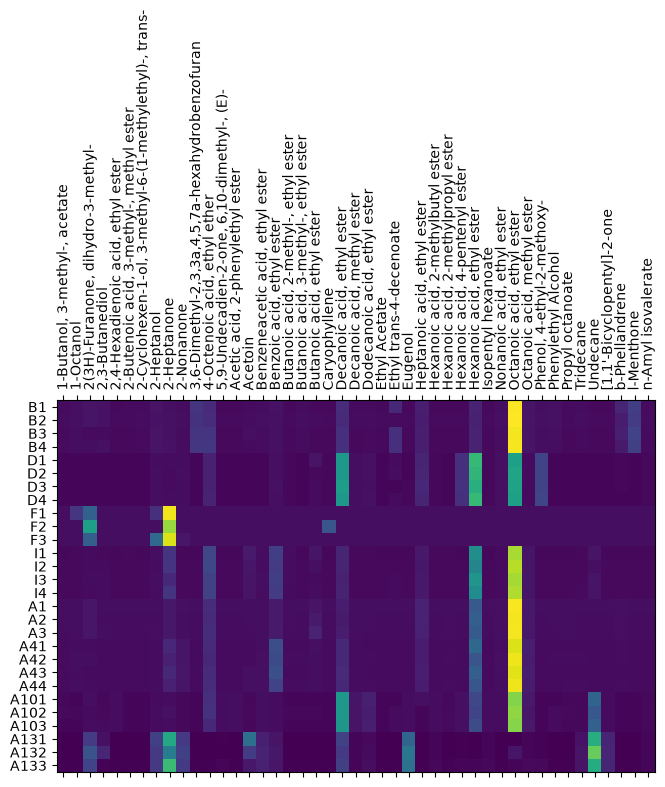

In [25]:
matshow(df[odour_cols].values)
gca().set_xticks(range(len(odour_cols)))
gca().set_xticklabels(odour_cols, rotation=90)
gca().set_yticks(range(len(df)))
gca().set_yticklabels([f"{row['Sample']}{row['Replicate']}" for _, row in df.iterrows()]);

In [6]:
from lucia_stats import erecta 
reload(erecta)

<module 'lucia_stats.erecta' from '/Users/sinatootoonian/git/lucia-natural-odour-stats/lucia_stats/erecta.py'>

In [19]:
reload(lucia_data)
reload(erecta)
A = erecta.Analysis(k=7)
results = A.fit_models()#results=results)

In [20]:
A.compute_sparsity()
A.compute_pc_var_overlap()
A.compute_confusion_matrices()
A.compute_p_values(n_rand=1000)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:23<00:00, 42.11it/s]


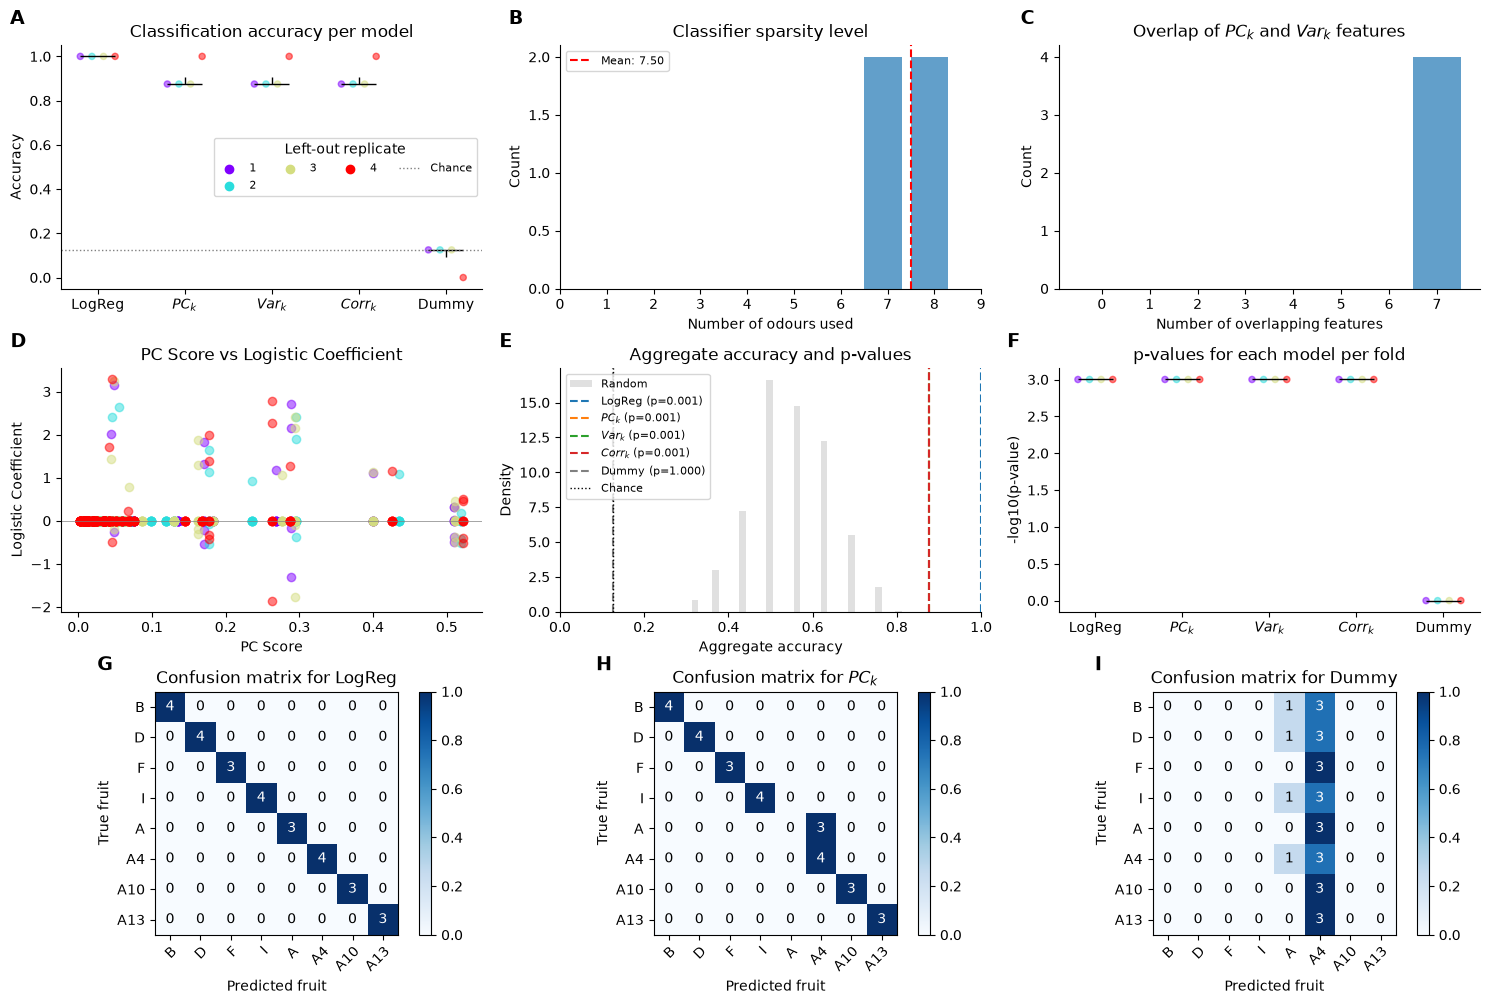

In [21]:
reload(erecta)
pr = erecta.PlotResults(A)
pr.plot_figure()